## Tarea 2 - Esteban Sánchez y Úrsula Sáez

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import ShuffleSplit
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance

In [2]:
data_train=pd.read_csv('train_redshift.csv')
data_test=pd.read_csv('test_redshift.csv')

## 1. Exploración inicial del conjunto de entrenamiento

In [3]:
data_train # Visualización de los datos

,objno_deep2,ra_deep2,dec_deep2,zquality,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor,flag_cfhtls,cfhtls_source,subaru_source,zhelio
0,13027624,214.812895,52.987945,1,25.536802,25.462694,25.331811,24.767236,24.867649,24.539227,0,0,-99,1.664840
1,12020064,214.693819,52.637015,4,23.802174,23.591218,23.290410,22.990565,23.018509,22.496892,0,0,0,1.314826
2,13035227,214.994798,53.051865,4,23.661166,22.389709,21.359927,20.786062,20.839287,20.466936,0,0,-99,0.297696
3,13039861,215.448870,53.106100,2,24.590983,23.872463,23.713001,23.670067,23.628797,23.663545,0,0,-99,1.159324
4,12004737,214.150124,52.436439,4,24.374535,24.226175,23.892377,23.263941,23.267458,22.990853,0,0,0,0.811566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19052,14017398,215.692246,53.437719,4,24.240796,24.205122,23.926456,23.528897,-99.000000,22.909429,0,1,-99,0.828503
19053,12005341,213.978285,52.419221,1,26.528255,25.084797,23.840316,23.301013,-99.000000,23.286571,0,1,1,0.373158
19054,11020060,213.900876,52.076499,1,23.596916,22.994620,22.683025,22.793867,-99.000000,22.622676,244,1,1,0.253488
19055,13032614,215.313935,53.052152,4,24.128220,23.855998,23.652930,23.422120,23.442838,23.146123,0,0,-99,1.449821


In [4]:
# Revisamos características de los datos
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19057 entries, 0 to 19056
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   objno_deep2    19057 non-null  int64  
 1   ra_deep2       19057 non-null  float64
 2   dec_deep2      19057 non-null  float64
 3   zquality       19057 non-null  int64  
 4   u_apercor      19057 non-null  float64
 5   g_apercor      19057 non-null  float64
 6   r_apercor      19057 non-null  float64
 7   i_apercor      19057 non-null  float64
 8   i2_apercor     19057 non-null  float64
 9   z_apercor      19057 non-null  float64
 10  flag_cfhtls    19057 non-null  int64  
 11  cfhtls_source  19057 non-null  int64  
 12  subaru_source  19057 non-null  int64  
 13  zhelio         19057 non-null  float64
dtypes: float64(9), int64(5)
memory usage: 2.0 MB


In [5]:
data_train.duplicated().sum() # Revisamos si hay algún duplicado

np.int64(0)

In [6]:
data_train.describe() # Análisis estadístico de los datos

,objno_deep2,ra_deep2,dec_deep2,zquality,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor,flag_cfhtls,cfhtls_source,subaru_source,zhelio
count,1.905700e+04,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000,19057.000000
mean,1.250061e+07,214.775328,52.802919,3.102902,23.072000,22.072399,21.474566,21.037788,-22.943618,20.808852,22.200714,-1.924227,-47.986567,0.714946
std,9.721234e+05,0.601017,0.415641,1.313585,21.588971,20.738837,20.670669,20.667991,59.776041,20.659574,76.125181,14.914514,49.629275,0.417994
min,1.100167e+07,213.473160,51.929113,-2.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,-0.078525
25%,1.200843e+07,214.310464,52.476931,2.000000,23.671897,23.237811,22.598163,22.014806,-99.000000,21.711408,0.000000,0.000000,-99.000000,0.396693
50%,1.300380e+07,214.782577,52.810978,4.000000,24.323693,23.911843,23.415690,22.912288,21.885385,22.634205,0.000000,0.000000,0.000000,0.688533
75%,1.304796e+07,215.223139,53.111788,4.000000,25.003003,24.439543,23.896741,23.498121,23.242554,23.295065,0.000000,1.000000,0.000000,0.979685
max,1.410175e+07,216.098062,53.694992,4.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,253.000000,1.000000,1.000000,4.500611


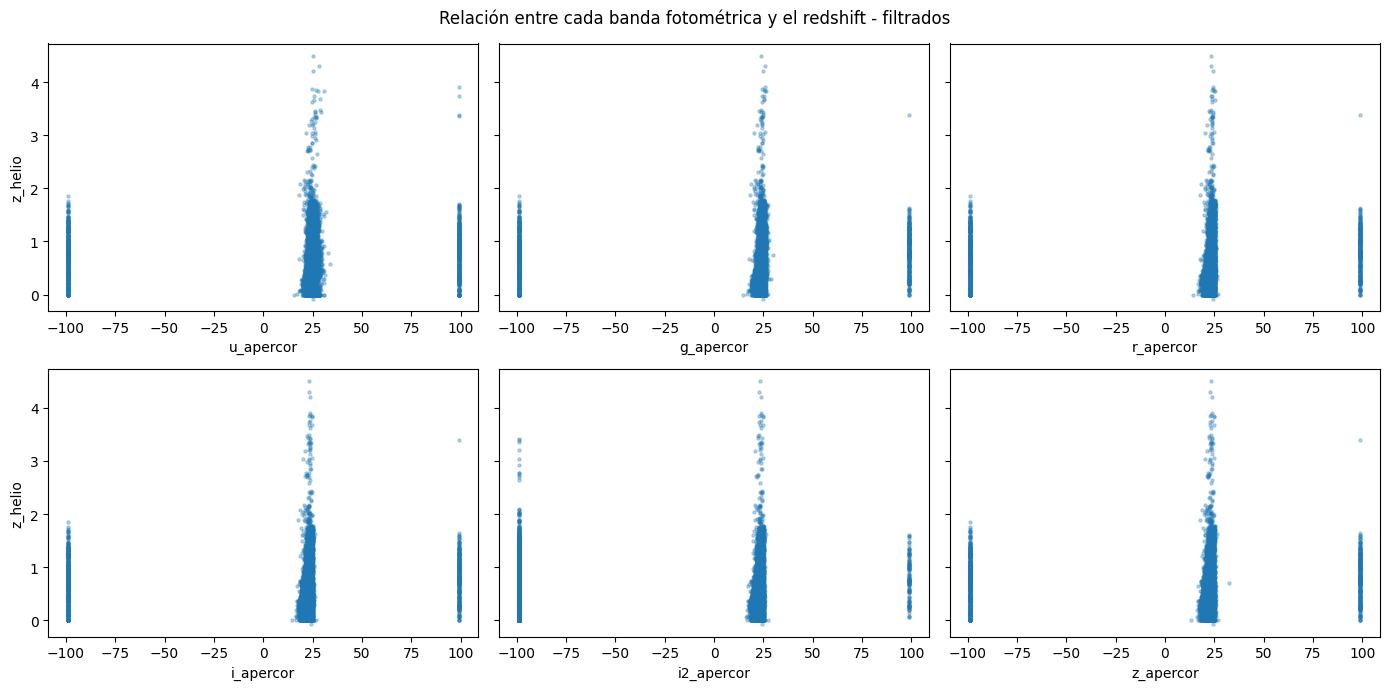

In [7]:
# Gráficos de los datos para proceder a la limpieza

cols = ['u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'i2_apercor','z_apercor']

X_train = data_train[cols]
y_train = data_train['zhelio'].values

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, col in zip(axes.flat, cols):
    ax.scatter(X_train[col], y_train, s=5, alpha=0.3)
    ax.set_xlabel(col)
axes[0, 0].set_ylabel('z_helio')
axes[1, 0].set_ylabel('z_helio')
plt.suptitle('Relación entre cada banda fotométrica y el redshift - filtrados')
plt.tight_layout()
plt.show()

## 2. Preparación de los datos para el modelamiento

Se filtraron datos de bandas con valor -99 y 99 ya que al analizar el gráfico anterior, se observa una concentración inusual de datos en -99 y 99 para todas las bandas, correspondiendo a un problema con la fotometría.

Además se filtró $zquality >=3$ debido a que estos valores corresponden a un 95% de probabilidad de que el redshift esté bien medido, asegurando una correcta calidad de los datos.

In [8]:
# Calculo de la cantidad de datos correspondiente a cada valor de 'zquality'

n4 = (data_train['zquality'] == 4).sum()
n3 = (data_train['zquality'] == 3).sum()
n2 = (data_train['zquality'] == 2).sum()
n1 = (data_train['zquality'] == 1).sum()
n0 = (data_train['zquality'] == 0).sum()
nm1 = (data_train['zquality'] == -1).sum()
nm2 = (data_train['zquality'] == -2).sum()

print(f"Cantidad de datos con zquality=4: {n4}")
print(f"Cantidad de datos con zquality=3: {n3}")
print(f"Cantidad de datos con zquality=2: {n2}")
print(f"Cantidad de datos con zquality=1: {n1}")
print(f"Cantidad de datos con zquality=0: {n0}")
print(f"Cantidad de datos con zquality=-1: {nm1}")
print(f"Cantidad de datos con zquality=-2: {nm2}")

Cantidad de datos con zquality=4: 11589
Cantidad de datos con zquality=3: 1890
Cantidad de datos con zquality=2: 2577
Cantidad de datos con zquality=1: 2556
Cantidad de datos con zquality=0: 71
Cantidad de datos con zquality=-1: 144
Cantidad de datos con zquality=-2: 230


In [9]:
good_quality= n4+n3
print(f"Porcentaje de datos con Zquality > 3: {(good_quality*100/len(data_train)):.1f} %")

Porcentaje de datos con Zquality > 3: 70.7 %


In [10]:
# Conteo por filtro de valores 99 y -99

for col in cols:
    n_m99 = (data_train[col] == -99).sum()
    n_99 = (data_train[col] == 99).sum()
    print(f"{col}: -99 = {n_m99}, 99 = {n_99}, Total = {n_m99 + n_99}")
df_filtrado = data_train[~data_train[cols].isin([-99, 99]).any(axis=1)]
df_filtrado = df_filtrado[df_filtrado['zquality'] >= 3]
print(f"Cantidad de datos filtrados: {len(df_filtrado)}")

u_apercor: -99 = 439, 99 = 396, Total = 835
g_apercor: -99 = 439, 99 = 285, Total = 724
r_apercor: -99 = 439, 99 = 282, Total = 721
i_apercor: -99 = 439, 99 = 286, Total = 725
i2_apercor: -99 = 7230, 99 = 119, Total = 7349
z_apercor: -99 = 439, 99 = 287, Total = 726
Cantidad de datos filtrados: 8439


## 3. Construcción y selección de variables predictoras

In [11]:
#Selección de colores para cada calidad de redshift
cols = ['u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'i2_apercor','z_apercor',
        'u-g', 'g-r', 'r-i', 'i-z', 'i2-z'] # Columnas nuevas de color para el data train
df_filtrado["u-g"] = df_filtrado["u_apercor"]-df_filtrado["g_apercor"]
df_filtrado["g-r"] = df_filtrado["g_apercor"]-df_filtrado["r_apercor"]
df_filtrado["r-i"] = df_filtrado["r_apercor"]-df_filtrado["i_apercor"]
df_filtrado["i-z"] = df_filtrado["i_apercor"]-df_filtrado["z_apercor"]
df_filtrado["i2-z"] = df_filtrado["i2_apercor"]-df_filtrado["z_apercor"]

data_test["u-g"] = data_test["u_apercor"]-data_test["g_apercor"]
data_test["g-r"] = data_test["g_apercor"]-data_test["r_apercor"]
data_test["r-i"] = data_test["r_apercor"]-data_test["i_apercor"]
data_test["i-z"] = data_test["i_apercor"]-data_test["z_apercor"]
data_test["i2-z"] = data_test["i2_apercor"]-data_test["z_apercor"]

In [12]:
# Variables predictorias
X_train_f = df_filtrado[cols]
y_train_f = df_filtrado['zhelio'].values

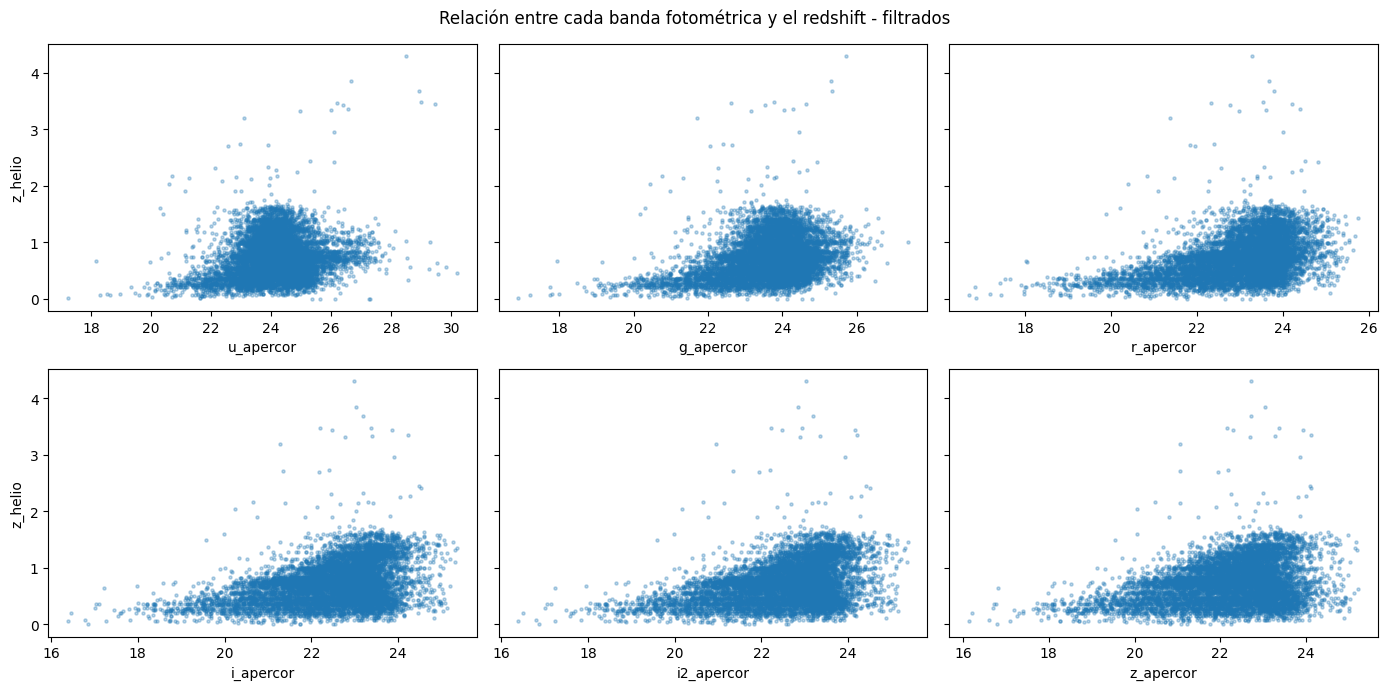

In [13]:
# Gráfico de los datos ya filtrados

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, col in zip(axes.flat, cols):
    ax.scatter(X_train_f[col], y_train_f, s=5, alpha=0.3)
    ax.set_xlabel(col)
axes[0, 0].set_ylabel('z_helio')
axes[1, 0].set_ylabel('z_helio')
plt.suptitle('Relación entre cada banda fotométrica y el redshift - filtrados')
plt.tight_layout()
plt.show()

## 4. Separación interna entre entrenamiento y validación, o uso de validación cruzada.

In [14]:
cv = ShuffleSplit(n_splits=20, test_size=0.3, random_state=0)
scores_arbol = cross_val_score(DecisionTreeRegressor(random_state=0), X_train_f, y_train_f, cv=cv, scoring='neg_mean_squared_error')
mse_arbol = -scores_arbol

print(f"Árbol único, MSE promedio: {mse_arbol.mean():.4f}, desviación estándar: {mse_arbol.std():.4f}")

Árbol único, MSE promedio: 0.0418, desviación estándar: 0.0085


In [15]:
dt = DecisionTreeRegressor(random_state=0)
dt.fit(X_train_f, y_train_f)

cv_scores = cross_val_score(DecisionTreeRegressor(random_state=0), X_train_f, y_train_f, cv=5)
print(f"Cross-validation R² (5-fold): {np.mean(cv_scores):.4f}")

Cross-validation R² (5-fold): 0.6870


## 5. Entrenamiento de un modelo baseline con `DecisionTreeRegressor`.

In [16]:
# Separar los datos en conjuntos de entrenamiento y validación
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_f, y_train_f, test_size=0.3, random_state=0)

Entrenamiento de un modelo simple de Decission tree

In [17]:
dt_base = DecisionTreeRegressor(random_state=0)
dt_base.fit(X_tr, y_tr)

y_pred_tr = dt_base.predict(X_tr)
y_pred_val = dt_base.predict(X_val)

mse_train_dt = np.mean((y_tr - y_pred_tr)**2)
mse_val_dt = np.mean((y_val - y_pred_val)**2)

print(f"MSE train: {mse_train_dt:.4f}")
print(f"MSE validación: {mse_val_dt:.4f}")

delta_z = (y_val - y_pred_val) / (1 + y_val)
sigma_nmad = 1.48 * np.median(np.abs(delta_z - np.median(delta_z)))
eta_outliers = np.mean(np.abs(delta_z) > 0.15)

print(f"sigma_NMAD: {sigma_nmad:.4f}")
print(f"Fracción de outliers (eta): {eta_outliers:.4f}")

MSE train: 0.0000
MSE validación: 0.0499
sigma_NMAD: 0.0204
Fracción de outliers (eta): 0.0509


### 6. Entrenamiento de algún método de ensamble.
* RandomForestRegressor
* ExtraTreesRegressor
* GradientBoostingRegressor
* HistGradientBoostingRegressor

Decidimos probar con distintos métodos para ver cómo se comportaba su MSE para éste contexto, y así inclinarnos por alguno para realizar la comparación con el modelo baseline.

Random Forest

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(n_estimators=50, random_state=0)
rf_base.fit(X_tr, y_tr)

y_pred_tr_rf = rf_base.predict(X_tr)
y_pred_val_rf = rf_base.predict(X_val)

mse_train_rf = np.mean((y_tr - y_pred_tr_rf)**2)
mse_val_rf = np.mean((y_val - y_pred_val_rf)**2)

print(f"MSE train (RF): {mse_train_rf:.4f}")
print(f"MSE validación (RF): {mse_val_rf:.4f}")

delta_z = (y_val - y_pred_val_rf) / (1 + y_val)
sigma_nmad = 1.48 * np.median(np.abs(delta_z - np.median(delta_z)))
eta_outliers = np.mean(np.abs(delta_z) > 0.15)

print(f"sigma_NMAD: {sigma_nmad:.4f}")
print(f"Fracción de outliers (eta): {eta_outliers:.4f}")

cv_scores_rf = cross_val_score(RandomForestRegressor(n_estimators=200, random_state=0), X_tr, y_tr, cv=5)
print(f"Cross-validation R² (5-fold): {np.mean(cv_scores_rf):.4f}")

MSE train (RF): 0.0030
MSE validación (RF): 0.0357
sigma_NMAD: 0.0155
Fracción de outliers (eta): 0.0387
Cross-validation R² (5-fold): 0.8346


ExtraTreeRegressor

In [19]:
from sklearn.ensemble import ExtraTreesRegressor
et_base = ExtraTreesRegressor(n_estimators=50, random_state=0)
et_base.fit(X_tr, y_tr)

y_pred_tr_et = et_base.predict(X_tr)
y_pred_val_et = et_base.predict(X_val)

mse_train_et = np.mean((y_tr - y_pred_tr_et)**2)
mse_val_et = np.mean((y_val - y_pred_val_et)**2)

print(f"MSE train (ET): {mse_train_et:.4f}")
print(f"MSE validación (ET): {mse_val_et:.4f}")

delta_z_et = (y_val - y_pred_val_et) / (1 + y_val)
sigma_nmad_et = 1.48 * np.median(np.abs(delta_z_et - np.median(delta_z_et)))
eta_et = np.mean(np.abs(delta_z_et) > 0.15)

print(f"sigma_NMAD (ET): {sigma_nmad_et:.4f}")
print(f"Fracción de outliers (ET): {eta_et:.4f}")

cv_scores_et = cross_val_score(ExtraTreesRegressor(n_estimators=200, random_state=0), X_tr, y_tr, cv=5)
print(f"Cross-validation R² (5-fold): {np.mean(cv_scores_et):.4f}")

MSE train (ET): 0.0000
MSE validación (ET): 0.0348
sigma_NMAD (ET): 0.0167
Fracción de outliers (ET): 0.0344
Cross-validation R² (5-fold): 0.8432


GradientBoostingRegressor

In [20]:
from sklearn.ensemble import GradientBoostingRegressor
gb_base = GradientBoostingRegressor(n_estimators=50, random_state=0)
gb_base.fit(X_tr, y_tr)

y_pred_tr_gb = gb_base.predict(X_tr)
y_pred_val_gb = gb_base.predict(X_val)

mse_train_gb = np.mean((y_tr - y_pred_tr_gb)**2)
mse_val_gb = np.mean((y_val - y_pred_val_gb)**2)
print(f"MSE train (GB): {mse_train_gb:.4f}")
print(f"MSE validación (GB): {mse_val_gb:.4f}")

delta_z_gb = (y_val - y_pred_val_gb) / (1 + y_val)
sigma_nmad_gb = 1.48 * np.median(np.abs(delta_z_gb - np.median(delta_z_gb)))
eta_gb = np.mean(np.abs(delta_z_gb) > 0.15)

print(f"sigma_NMAD (GB): {sigma_nmad_gb:.4f}")
print(f"Fracción de outliers (GB): {eta_gb:.4f}")

cv_scores_gb = cross_val_score(GradientBoostingRegressor(n_estimators=200, random_state=0), X_tr, y_tr, cv=5)
print(f"Cross-validation R² (5-fold): {np.mean(cv_scores_gb):.4f}")

MSE train (GB): 0.0188
MSE validación (GB): 0.0452
sigma_NMAD (GB): 0.0422
Fracción de outliers (GB): 0.0604
Cross-validation R² (5-fold): 0.7953


HistGradientBoostingRegressor

In [21]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_base = HistGradientBoostingRegressor(max_iter=50, random_state=0)
hgb_base.fit(X_tr, y_tr)

y_pred_tr_hgb = hgb_base.predict(X_tr)
y_pred_val_hgb = hgb_base.predict(X_val)

mse_train_hgb = np.mean((y_tr - y_pred_tr_hgb)**2)
mse_val_hgb = np.mean((y_val - y_pred_val_hgb)**2)
print(f"MSE train (HGB): {mse_train_hgb:.4f}")
print(f"MSE validación (HGB): {mse_val_hgb:.4f}")

delta_z_hgb = (y_val - y_pred_val_hgb) / (1 + y_val)
sigma_nmad_hgb = 1.48 * np.median(np.abs(delta_z_hgb - np.median(delta_z_hgb)))
eta_hgb = np.mean(np.abs(delta_z_hgb) > 0.15)

print(f"sigma_NMAD (HGB): {sigma_nmad_hgb:.4f}")
print(f"Fracción de outliers (HGB): {eta_hgb:.4f}")

cv_scores_hgb = cross_val_score(HistGradientBoostingRegressor(max_iter=200, random_state=0), X_tr, y_tr, cv=5)
print(f"Cross-validation R² (5-fold): {np.mean(cv_scores_hgb):.4f}")

MSE train (HGB): 0.0116
MSE validación (HGB): 0.0409
sigma_NMAD (HGB): 0.0234
Fracción de outliers (HGB): 0.0419
Cross-validation R² (5-fold): 0.8197


Comparación ensambles MSE

In [22]:
datos = [
    {
        "Modelo": "RandomForest",
        "MSE train": f"{mse_train_rf:.4f}",
        "MSE test": f"{mse_val_rf:.4f}",
    },
    {
        "Modelo": "ExtraTreeRegressor",
        "MSE train": f"{mse_train_et:.4f}",
        "MSE test": f"{mse_val_et:.4f}",
    },
    {
        "Modelo": "GradientBoostingRegressor",
        "MSE train": f"{mse_train_gb:.4f}",
        "MSE test": f"{mse_val_gb:.4f}",
    },
    {
        "Modelo": "HistGradientBoostingRegressor",
        "MSE train":  f"{mse_train_hgb:.4f}",
        "MSE test":  f"{mse_val_hgb:.4f}" ,
    }
]

results_complexity = pd.DataFrame(datos)
results_complexity

,Modelo,MSE train,MSE test
0,RandomForest,0.0030,0.0357
1,ExtraTreeRegressor,0.0000,0.0348
2,GradientBoostingRegressor,0.0188,0.0452
3,HistGradientBoostingRegressor,0.0116,0.0409


Nos quedamos con `Random Forest` porque tiene un MSE test y MSE train más bajo.Por otro lado, descartamos el modelo `ExtraTreeRegresor`, ya que al tener un MSE train igual a 0,0000, intuímos que el modelo pudo hacer overfitting.

### 7. Optimización de hiperparámetros(puede usar GridSearchCV, RandomizedSearchCV, Optuna, etc.)

In [23]:
#Seleccion de hiperparámetros
from sklearn.model_selection import GridSearchCV, KFold, cross_val_predict

parameters_dt = {
    'max_depth': [None, 3, 6, 12],
    'min_samples_leaf': [1, 5, 10, 20],
}

parameters_rf = {
    'max_depth': [None, 3, 6, 12],
    'max_features': [None, 2, 4, 8],
    'n_estimators': [50, 100, 200, 400],
    'min_samples_leaf': [1, 5, 10, 20],
}

In [24]:
# Optimización a Decission Tree
from sklearn.model_selection import RandomizedSearchCV

grid_dt = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=5),
    parameters_dt,
    cv=KFold(n_splits=5, shuffle=True, random_state=5),
)
grid_dt.fit(X_tr, y_tr)

print(f"Mejores hiperparámetros (Árbol de Decisión): {grid_dt.best_params_}")
print(f"Mejor score (R²) en validación cruzada: {grid_dt.best_score_:.4f}")

Mejores hiperparámetros (Árbol de Decisión): {'min_samples_leaf': 10, 'max_depth': None}
Mejor score (R²) en validación cruzada: 0.7914


In [25]:
# Optimización de método de ensamble
from sklearn.model_selection import RandomizedSearchCV

grid_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=5),
    parameters_rf,
    cv=KFold(n_splits=5, shuffle=True, random_state=5),
)
grid_rf.fit(X_tr, y_tr)

print("Mejores hiperparámetros(Random Forest):", grid_rf.best_params_)
print(f"Mejor score (CV, R²): {grid_rf.best_score_:.4f}")

Mejores hiperparámetros(Random Forest): {'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 12}
Mejor score (CV, R²): 0.8333


### 8. Comparación de modelos usando MSE

Volvemos a entrenar el código pero con los hiperparámetros

In [26]:
dt_opt = DecisionTreeRegressor(random_state=5, **grid_dt.best_params_)
dt_opt.fit(X_tr, y_tr)

y_pred_tr_opt = dt_opt.predict(X_tr)
y_pred_val_opt = dt_opt.predict(X_val)

mse_train_dt_opt = np.mean((y_tr - y_pred_tr_opt)**2)
mse_val_dt_opt = np.mean((y_val - y_pred_val_opt)**2)

print(f"MSE train: {mse_train_dt_opt:.4f}")
print(f"MSE validación: {mse_val_dt_opt:.4f}")

delta_z__dt_opt = (y_val - y_pred_val_opt) / (1 + y_val)
sigma_nmad_dt_opt = 1.48 * np.median(np.abs(delta_z__dt_opt - np.median(delta_z__dt_opt)))
eta_outliers_dt_opt = np.mean(np.abs(delta_z__dt_opt) > 0.15)

print(f"sigma_NMAD: {sigma_nmad_dt_opt:.4f}")
print(f"Fracción de outliers (eta): {eta_outliers_dt_opt:.4f}")

cv_scores_dt_opt = cross_val_score(DecisionTreeRegressor(random_state=5, **grid_dt.best_params_), X_tr, y_tr, cv=5)
print(f"Cross-validation R² (5-fold): {np.mean(cv_scores_dt_opt):.4f}")

MSE train: 0.0149
MSE validación: 0.0436
sigma_NMAD: 0.0224
Fracción de outliers (eta): 0.0438
Cross-validation R² (5-fold): 0.7920


In [27]:
rf_opt = RandomForestRegressor(random_state=5, **grid_rf.best_params_)
rf_opt.fit(X_tr, y_tr)

y_pred_tr_rf_opt = rf_opt.predict(X_tr)
y_pred_val_rf_opt = rf_opt.predict(X_val)

mse_train_rf_opt = np.mean((y_tr - y_pred_tr_rf_opt)**2)
mse_val_rf_opt = np.mean((y_val - y_pred_val_rf_opt)**2)

print(f"MSE train (RF): {mse_train_rf_opt:.4f}")
print(f"MSE validación (RF): {mse_val_rf_opt:.4f}")

delta_z_rf_opt = (y_val - y_pred_val_rf_opt) / (1 + y_val)
sigma_nmad_rf_opt = 1.48 * np.median(np.abs(delta_z_rf_opt - np.median(delta_z_rf_opt)))
eta_outliers_rf_opt = np.mean(np.abs(delta_z_rf_opt) > 0.15)

print(f"sigma_NMAD: {sigma_nmad_rf_opt:.4f}")
print(f"Fracción de outliers (eta): {eta_outliers_rf_opt:.4f}")

cv_scores_rf_opt = cross_val_score(RandomForestRegressor(random_state=5, **grid_rf.best_params_),
                                                         X_tr, y_tr, cv=5)
print(f"Cross-validation R² (5-fold): {np.mean(cv_scores_rf_opt):.4f}")

MSE train (RF): 0.0117
MSE validación (RF): 0.0395
sigma_NMAD: 0.0162
Fracción de outliers (eta): 0.0415
Cross-validation R² (5-fold): 0.8376


In [28]:
results = [
    {
        "Modelo": "DecisionTree",
        "Features Usadas": len(cols),
        "Hiperámetros": str(grid_dt.best_params_),
        "Mejor score": float(grid_dt.best_score_),
        "MSE train": float(mse_train_dt_opt),
        "MSE test": float(mse_val_dt_opt),
        "sigma_NMAD": float(sigma_nmad_dt_opt),
        "eta_outliers": float(eta_outliers_dt_opt),
 },
    {
        "Modelo": "RandomForest",
        "Features Usadas": len(cols),
        "Hiperámetros": str(grid_rf.best_params_),
        "Mejor score": float(grid_rf.best_score_),
        "MSE train": float(mse_train_rf_opt),
        "MSE test": float(mse_val_rf_opt),
        "sigma_NMAD": float(sigma_nmad_rf_opt),
        "eta_outliers": float(eta_outliers_rf_opt),
    },
]

pd.set_option('display.max_colwidth', None)   # No cortar texto de las celdas
comparacion_modelos = pd.DataFrame(results)
comparacion_modelos

,Modelo,Features Usadas,Hiperámetros,Mejor score,MSE train,MSE test,sigma_NMAD,eta_outliers
0,DecisionTree,11,"{'min_samples_leaf': 10, 'max_depth': None}",0.791433,0.014900,0.043645,0.022419,0.043839
1,RandomForest,11,"{'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 12}",0.833286,0.011713,0.039534,0.016246,0.041469


Finalmente, al optimizar ambos modelos, se optó por designar `Random Forest` como el mejor modelo a entrenar, dado que su $R^2 score$ es más alto, mientras que tanto sus valores de $MSE$, sigma_NMAD, $\eta$ outliers son más bajos que `Decission Tree`, lo que nos indica un mejor desempeño del modelo.

u-g           0.370882
r-i           0.249361
i-z           0.210350
g-r           0.149545
i_apercor     0.008213
i2-z          0.007946
g_apercor     0.001400
u_apercor     0.000771
i2_apercor    0.000686
z_apercor     0.000496
r_apercor     0.000350
dtype: float64
u-g           0.299908
r-i           0.228740
g-r           0.202759
i-z           0.155769
i2-z          0.086673
u_apercor     0.008497
g_apercor     0.004795
z_apercor     0.003947
r_apercor     0.003858
i2_apercor    0.002548
i_apercor     0.002507
dtype: float64


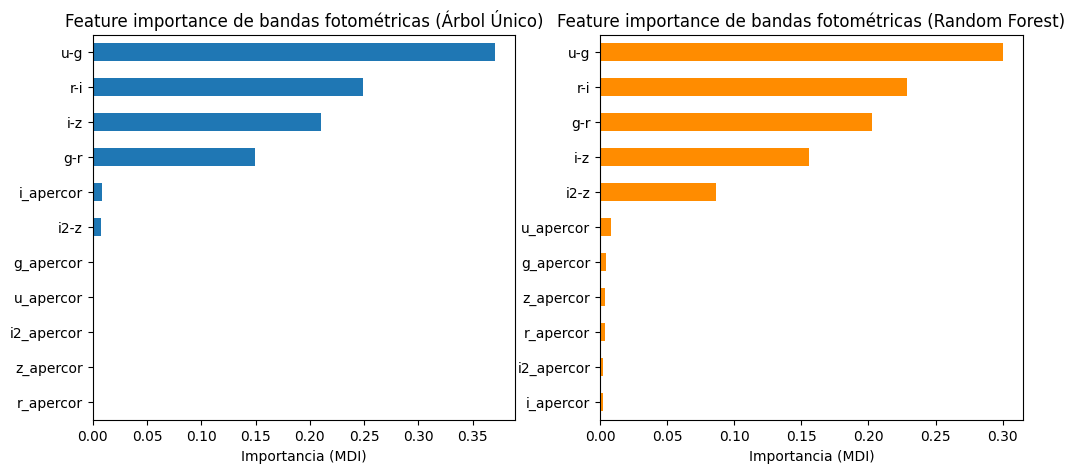

In [29]:
importancias_dt = pd.Series(
    dt_opt.feature_importances_,
    index=X_train_f.columns
).sort_values(ascending=False)

importancias_rf = pd.Series(
    rf_opt.feature_importances_,
    index=X_train_f.columns
).sort_values(ascending=False)

print(importancias_dt)
print(importancias_rf)

fig, ax = plt.subplots(1,2, figsize=(12, 5))

ax1= ax[0]
importancias_dt.plot(kind='barh', ax=ax1)
ax1.set_xlabel('Importancia (MDI)')
ax1.set_title('Feature importance de bandas fotométricas (Árbol Único)')
ax1.invert_yaxis()

ax2 = ax[1]
importancias_rf.plot(kind='barh', ax=ax2, color='darkorange')
ax2.set_xlabel('Importancia (MDI)')
ax2.set_title('Feature importance de bandas fotométricas (Random Forest)')
ax2.invert_yaxis()

plt.show()

g-r           0.661488
r-i           0.542423
u-g           0.408313
i-z           0.355906
i2-z          0.029542
i_apercor     0.010245
g_apercor     0.003222
u_apercor     0.002824
i2_apercor    0.002169
z_apercor     0.001294
r_apercor     0.000583
dtype: float64
g-r           0.492724
r-i           0.354164
u-g           0.298871
i-z           0.149265
i2-z          0.060052
u_apercor     0.012823
g_apercor     0.003766
z_apercor     0.003163
i2_apercor    0.002347
r_apercor     0.002264
i_apercor     0.001457
dtype: float64


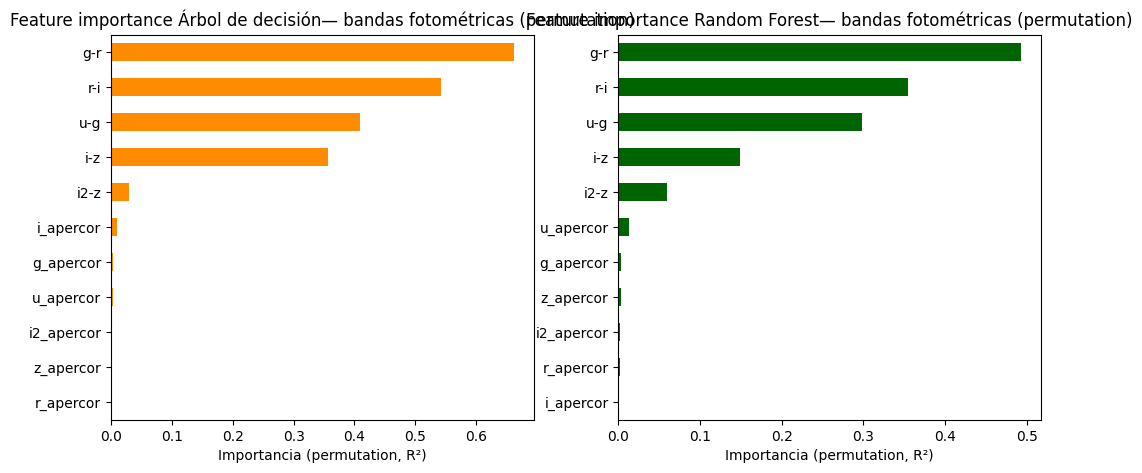

In [30]:
from sklearn.inspection import permutation_importance

perm_dt = permutation_importance(dt_opt, X_train_f, y_train_f, n_repeats=10, random_state=0, scoring='r2')
perm_rf = permutation_importance(rf_opt, X_train_f, y_train_f, n_repeats=10, random_state=0, scoring='r2')

importancias_perm_dt = pd.Series(perm_dt.importances_mean, index=X_train_f.columns).sort_values(ascending=False)
print(importancias_perm_dt)

importancias_perm_rf = pd.Series(perm_rf.importances_mean, index=X_train_f.columns).sort_values(ascending=False)
print(importancias_perm_rf)

fig, ax = plt.subplots(1,2, figsize=(12, 5))
ax1 = ax[0]
importancias_perm_dt.plot(kind='barh', color='darkorange', ax=ax1)
ax1.set_xlabel('Importancia (permutation, R²)')
ax1.set_title('Feature importance Árbol de decisión— bandas fotométricas (permutation)')
ax1.invert_yaxis()

ax2 = ax[1]
importancias_perm_rf.plot(kind='barh', color='darkgreen', ax=ax2)
ax2.set_xlabel('Importancia (permutation, R²)')
ax2.set_title('Feature importance Random Forest— bandas fotométricas (permutation)')
ax2.invert_yaxis()

plt.show()

### 9. Selección del modelo final

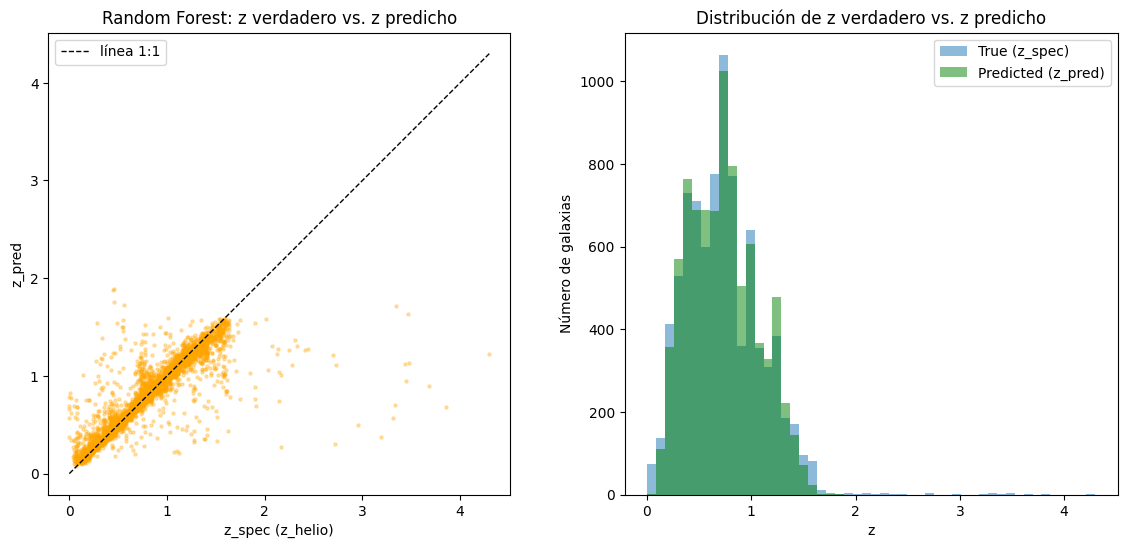

Numero de muestras: 8439
Numero de muestras predichas: 8439


In [31]:
best_model = grid_rf.best_estimator_

y_pred = cross_val_predict(best_model, X_train_f, y_train_f, cv=KFold(n_splits=5, shuffle=True, random_state=5))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax1 = axes[0]
ax1.scatter(y_train_f, y_pred, s=5, alpha=0.3, color='orange')
ax1.plot([0, y_train_f.max()], [0, y_train_f.max()], 'k--', lw=1, label='línea 1:1')
ax1.set_xlabel('z_spec (z_helio)')
ax1.set_ylabel('z_pred')
ax1.axis('square')
ax1.legend()
ax1.set_title('Random Forest: z verdadero vs. z predicho')

ax2 = axes[1]
ax2.hist(y_train_f, bins=50, density=False, alpha=0.5, range=(0, y_train_f.max()), label='True (z_spec)')
ax2.hist(y_pred, bins=50, density=False, alpha=0.5, range=(0, y_train_f.max()), color='g', label='Predicted (z_pred)')
ax2.set_xlabel('z')
ax2.set_ylabel('Número de galaxias')
ax2.legend()
ax2.set_title('Distribución de z verdadero vs. z predicho')
plt.show()

print(f"Numero de muestras: {len(y_train_f)}")
print(f"Numero de muestras predichas: {len(y_pred)}")

### 10. Generación de predicciones para `test_redshift.csv`

In [32]:
X_test = data_test[cols]
y_pred_final = best_model.predict(X_test)

In [33]:
predicciones = pd.DataFrame({'objno_deep2': data_test['objno_deep2'], 'z_pred': y_pred_final})
predicciones.to_csv('predicciones.csv', index=False)

## Preguntas finales
Respondan brevemente al final del notebook. En todas las preguntas, la respuesta debe apoyarse en gráficos o números específicos de su propio notebook, no en generalidades.

**Sobre la comparación de modelos:**

1. ¿Qué modelo obtuvo el menor MSE en validación?

**Respuesta:** El modelo con menor MSE test fue el de Random Forest, con un valor de *0.0352* en comparación con el modelo Decision Tree que obtuvo un MSE test de *0.0438*.

2. ¿Ese modelo fue elegido como modelo final? Justifiquen.

**Respuesta:** El Random Forest fue elegido ya que obtuvo el mejor desempeño considerando las métricas de *$R^2 score$*, *$\sigma_{NMAD}$*, *$\eta_{outliers}$*, además de tener valores bajos en MSE train y MSE test. Fue importante revisar el valor de *$\sigma_{NMAD}$* ya que al ser cercano a cero representa una menor dispersión de los datos, y por otro lado el valor de *$\eta_{outliers}$* también fue significativo a la hora de elegir el modelo ya que nos indica que mientras más bajo sea, menor va a ser el porcentaje de galaxias que presenten errores críticos.

3. ¿Qué diferencias observaron entre un árbol individual y los métodos de ensamble?

**Respuesta:** Principalmente el valor de las métricas tales como MSE, *$R^2 score$*, *$\sigma_{NMAD}$* y *$\eta_{outliers}$* y algunas de las features que fueron importantes para cada modelo.

**Sobre las variables:**

4. ¿Qué variables parecen ser más importantes para predecir el redshift?

**Respuesta:** La variable de color *u-g* principalmente, ya que en ambos modelos se mantuvo en una posición alta al momento de medir la importancia de esta. En general se presenta que los colores tienen una importancia mucho mayor que las bandas individuales.

5. Calculen la importancia de variables con al menos dos criterios distintos (por ejemplo, MDI y permutation importance). ¿Coinciden en el ranking? Si no coinciden, ¿a qué atribuyen la diferencia?

**Respuesta:** En Random Forest el orden de importancia no se mantiene estable debido a la multicolinealidad que existe entre las variables de color. Por otro lado, Decision Tree se construye a partir de un nodo raíz (*u-g*) el cual coincide con la variable que más utiliza para entrenarse.

**Sobre los errores del modelo:**

6. ¿En qué rangos de redshift falla más el modelo?

**Respuesta:** En el redshift cercano a cero y en aproximadamente 1.5 se observa que los valores se desvían del redshift real.

7. En el notebook de clase vimos que los métodos basados en árboles tienden a "estrechar" la distribución de predicciones (sobreestiman z bajos, subestiman z altos). ¿Observan este mismo efecto en su propio scatter $z_{\rm true}$
 vs. $z_{\rm pred}$? ¿En qué rango es más pronunciado, y coincide con una menor cantidad de galaxias de entrenamiento en ese rango?

**Respuesta:** Si se observa esta tendencia, y es más pronunciado en redshift mayor a 1.4 aproximadamente, donde los valores de z son un poco más bajos. También en ese rango coincidió que habían 300 galaxias aprox., en comparación a valores alrededor del *z=1*.

8. Si usaron oob_score en algún modelo, comparen ese valor con el de su validación cruzada. ¿Son consistentes? ¿Qué les dice eso sobre la confiabilidad de OOB para este dataset en particular?

**Respuesta:** No fue utilizado *oob_score* porque se calculó solo con el de validación cruzada ya que solo se puede aplicar a métodos de ensamble, por lo que no nos permitía compararlo con Decision Tree.

**Sobre el proceso:**

9. ¿Qué posibles fuentes de error o sesgo puede tener este enfoque?

**Respuesta:** En primer lugar los datos con los que se entrena el modelo, debido a que si no están previamente procesados este tendrá en consecuencia un peor desempeño. En segundo lugar el modelo pudo haber generado cierto sesgo hacia galaxias con redsfhit en un rango de $0.5 - 1.4$ ya que tenía más datos.

10. ¿Qué decisión metodológica tuvo mayor impacto en el resultado final?

**Respuesta:** Haber construido las variables predictoras de colores ya que el modelo tuvo un mejor rendimiento a diferencia del uso de bandas individuales. Además los colores presentaron una importancia mayor que las bandas tanto en MDI como al aplicar permutation importance.

11. ¿El modelo con menor MSE es necesariamente el mejor modelo desde el punto de vista científico? Justifiquen.

**Respuesta:** Si, aunque no necesariamente, porque si tiene un MSE muy bajo puede indicar que el modelo está haciendo overfitting, y no está aprendiendo solo memorizando los datos.